# Atharva Date b22ai045

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision.datasets import VOCSegmentation
import numpy as np
from sklearn.metrics import f1_score, jaccard_score
import time

In [ ]:

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

dataset_train = VOCSegmentation(root="./data", year='2012', image_set='train', download=True, transform=transform, target_transform=transform)
dataset_val = VOCSegmentation(root="./data", year='2012', image_set='val', download=True, transform=transform, target_transform=transform)
train_loader = DataLoader(dataset_train, batch_size=8, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=8, shuffle=False)

100%|██████████| 2.00G/2.00G [02:20<00:00, 14.2MB/s]


Extracting ./data/VOCtrainval_11-May-2012.tar to ./data
Using downloaded and verified file: ./data/VOCtrainval_11-May-2012.tar
Extracting ./data/VOCtrainval_11-May-2012.tar to ./data


In [ ]:
class SegNet(nn.Module):
    def __init__(self, backbone='vgg'):
        super(SegNet, self).__init__()
        if backbone == 'vgg':
            vgg = models.vgg16(pretrained=True)
            self.encoder = vgg.features
            dec_channels = [512, 256, 128, 64, 32]
        elif backbone == 'efficientnet':
            effnet = models.efficientnet_b0(pretrained=True)
            self.encoder = nn.Sequential(*list(effnet.children())[:-2])
            dec_channels = [1280, 640, 320, 160, 80]

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(dec_channels[0], dec_channels[1], kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(dec_channels[1]),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(dec_channels[1], dec_channels[2], kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(dec_channels[2]),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(dec_channels[2], dec_channels[3], kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(dec_channels[3]),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(dec_channels[3], dec_channels[4], kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(dec_channels[4]),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(dec_channels[4], 21, kernel_size=3, stride=2, padding=1, output_padding=1),
        )
        self.upsample = nn.Upsample(size=(256, 256), mode='bilinear', align_corners=False)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = self.upsample(x)
        return x


In [ ]:
def dice_score_multiclass(y_true, y_pred, num_classes):
    dice_scores = []
    for i in range(num_classes):
        y_true_i = (y_true == i).astype(np.int64)  # Changed to np.int64
        y_pred_i = (y_pred == i).astype(np.int64)  # Changed to np.int64
        intersection = np.sum(y_true_i * y_pred_i)
        dice_scores.append((2. * intersection) / (np.sum(y_true_i) + np.sum(y_pred_i) + 1e-7))
    return np.mean(dice_scores)

In [ ]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_pixels = 0, 0, 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        masks = masks.squeeze(1).long()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = torch.argmax(outputs, dim=1)
        total_correct += (pred == masks).sum().item()
        total_pixels += masks.numel()

    return total_loss / len(loader), total_correct / total_pixels

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_pixels = 0, 0, 0
    iou_scores, f1_scores, dice_scores = [], [], []

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            masks = masks.squeeze(1).long()

            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            pred = torch.argmax(outputs, dim=1)
            total_correct += (pred == masks).sum().item()
            total_pixels += masks.numel()

            y_true = masks.cpu().numpy().flatten()
            y_pred = pred.cpu().numpy().flatten()

            iou_scores.append(jaccard_score(y_true, y_pred, average='macro', zero_division=1))
            f1_scores.append(f1_score(y_true, y_pred, average='macro', zero_division=1))
            dice_scores.append(dice_score_multiclass(y_true, y_pred, num_classes=21))

    val_loss = total_loss / len(loader) if len(loader) > 0 else 0
    val_acc = total_correct / total_pixels if total_pixels > 0 else 0
    val_iou = np.mean(iou_scores) if iou_scores else 0
    val_f1 = np.mean(f1_scores) if f1_scores else 0
    val_dice = np.mean(dice_scores) if dice_scores else 0

    return val_loss, val_acc, val_iou, val_f1, val_dice

In [ ]:
# Setup and train
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vgg = SegNet("vgg").to(device)
model_eff = SegNet("efficientnet").to(device)
results = {}

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 160MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. 

In [ ]:
optimizer = optim.Adam(model_vgg.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
start_time = time.time()
for epoch in range(15):
    train_loss, train_acc = train(model_vgg, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_iou, val_f1, val_dice = evaluate(model_vgg, val_loader, criterion, device)
    print(f"VGG: Epoch {epoch+1}: Train Loss {train_loss:.4f}, Train Acc {train_acc:.4f}, Val Loss {val_loss:.4f}, Val Acc {val_acc:.4f}, IOU {val_iou:.4f}, F1 {val_f1:.4f}, Dice {val_dice:.4f}")
results["VGG"] = {"time": time.time() - start_time, "accuracy": val_acc, "iou": val_iou, "f1": val_f1, "dice": val_dice}


VGG: Epoch 1: Train Loss 0.7317, Train Acc 0.9186, Val Loss 0.2477, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
VGG: Epoch 2: Train Loss 0.2323, Train Acc 0.9451, Val Loss 0.2230, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
VGG: Epoch 3: Train Loss 0.2165, Train Acc 0.9451, Val Loss 0.2188, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
VGG: Epoch 4: Train Loss 0.2100, Train Acc 0.9451, Val Loss 0.2111, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
VGG: Epoch 5: Train Loss 0.2059, Train Acc 0.9451, Val Loss 0.2043, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
VGG: Epoch 6: Train Loss 0.2030, Train Acc 0.9451, Val Loss 0.2018, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
VGG: Epoch 7: Train Loss 0.2013, Train Acc 0.9451, Val Loss 0.2022, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
VGG: Epoch 8: Train Loss 0.2000, Train Acc 0.9451, Val Loss 0.2076, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
VGG: Epoch 9: Train Loss 0.1997, Train Acc 0.945

In [ ]:
optimizer = optim.Adam(model_eff.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
start_time = time.time()
for epoch in range(15):
    train_loss, train_acc = train(model_eff, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_iou, val_f1, val_dice = evaluate(model_eff, val_loader, criterion, device)
    print(f"Eff: Epoch {epoch+1}: Train Loss {train_loss:.4f}, Train Acc {train_acc:.4f}, Val Loss {val_loss:.4f}, Val Acc {val_acc:.4f}, IOU {val_iou:.4f}, F1 {val_f1:.4f}, Dice {val_dice:.4f}")
results["Eff"] = {"time": time.time() - start_time, "accuracy": val_acc, "iou": val_iou, "f1": val_f1, "dice": val_dice}


Eff: Epoch 1: Train Loss 0.4627, Train Acc 0.9236, Val Loss 0.2027, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
Eff: Epoch 2: Train Loss 0.1974, Train Acc 0.9451, Val Loss 0.1989, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
Eff: Epoch 3: Train Loss 0.1879, Train Acc 0.9451, Val Loss 0.1924, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
Eff: Epoch 4: Train Loss 0.1796, Train Acc 0.9451, Val Loss 0.1942, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
Eff: Epoch 5: Train Loss 0.1735, Train Acc 0.9450, Val Loss 0.1907, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
Eff: Epoch 6: Train Loss 0.1626, Train Acc 0.9449, Val Loss 0.1953, Val Acc 0.9406, IOU 0.4749, F1 0.4932, Dice 0.0470
Eff: Epoch 7: Train Loss 0.1583, Train Acc 0.9450, Val Loss 0.1879, Val Acc 0.9447, IOU 0.4725, F1 0.4858, Dice 0.0463
Eff: Epoch 8: Train Loss 0.1526, Train Acc 0.9457, Val Loss 0.1920, Val Acc 0.9420, IOU 0.4803, F1 0.5022, Dice 0.0478
Eff: Epoch 9: Train Loss 0.1444, Train Acc 0.947

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

def generate_segmentation_masks(model, loader, device, num_samples=5):
    model.eval()
    images_shown = 0

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            masks = masks.squeeze(1).long()
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for i in range(images.shape[0]):
                if images_shown >= num_samples:
                    return
                fig, ax = plt.subplots(1, 3, figsize=(12, 4))

                ax[0].imshow(images[i].permute(1, 2, 0).cpu().numpy())
                ax[0].set_title("Original Image")
                ax[0].axis("off")

                ax[1].imshow(masks[i].cpu().numpy(), cmap=cm.get_cmap('tab20b', 21)) # Or 'viridis', 'plasma' etc.

                ax[1].set_title("Ground Truth Mask")
                ax[1].axis("off")

                ax[2].imshow(preds[i].cpu().numpy(), cmap=cm.get_cmap('tab20b', 21))
                ax[2].set_title("Predicted Mask")
                ax[2].axis("off")

                plt.show()
                images_shown += 1

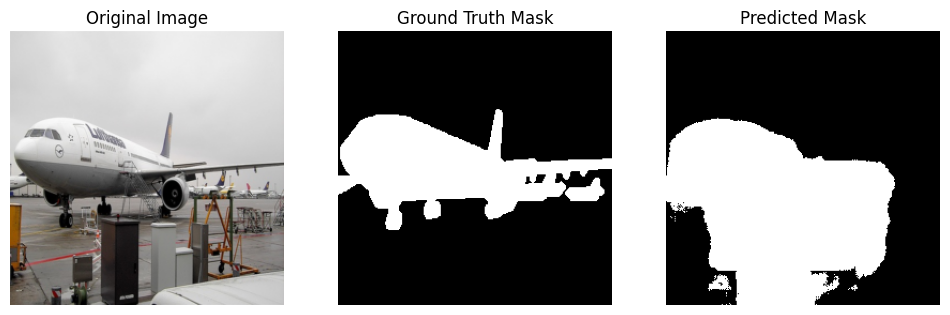

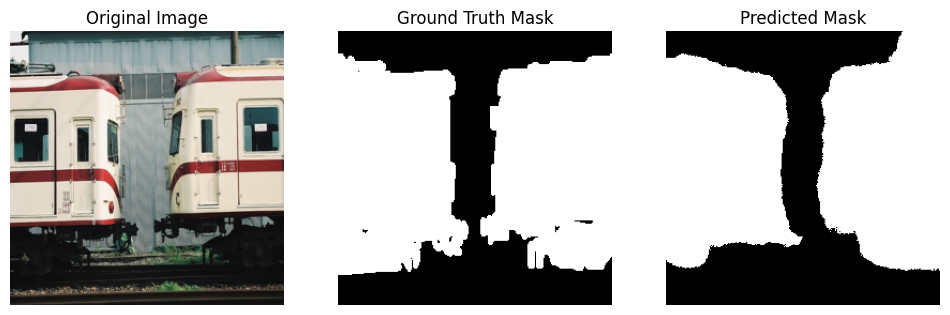

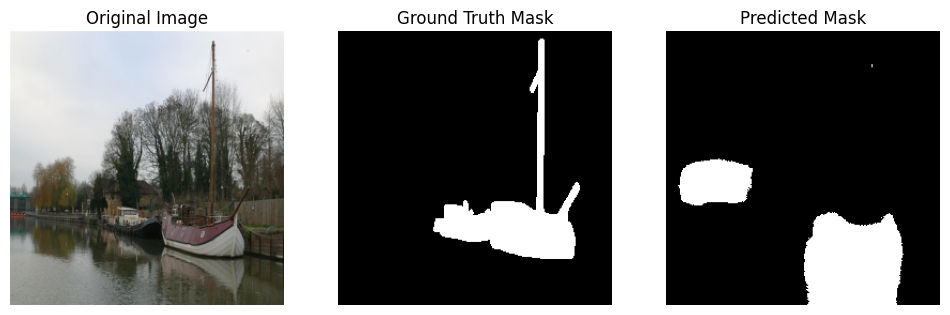

In [ ]:
generate_segmentation_masks(model1, test_loader, device)

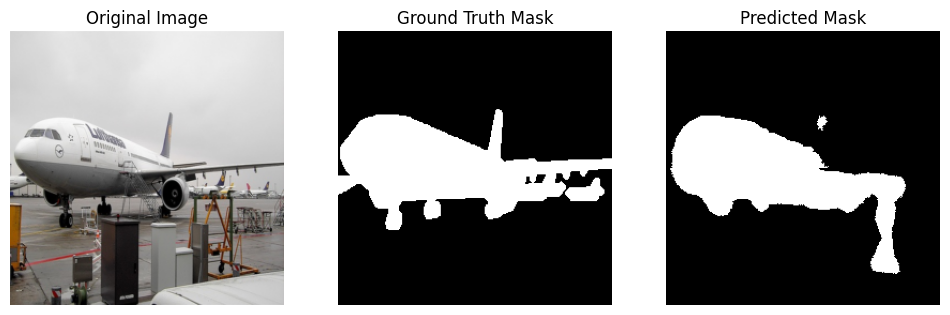

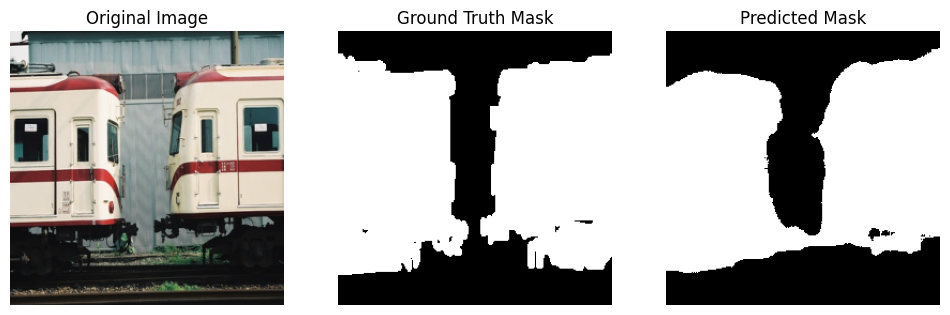

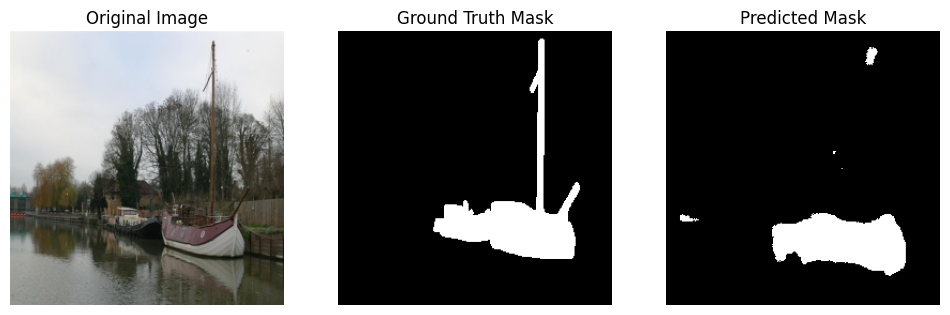

In [ ]:
generate_segmentation_masks(model2, test_loader, device)